In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

DATASET_DIR = Path("dataset")
pred = pd.read_csv("reports/envelope_1d_predictions.csv")

pred["error_type"] = "ok"
pred.loc[(pred["label"] == "no_burst") & (pred["predicted"] == "burst"), "error_type"] = "false_positive"
pred.loc[(pred["label"] == "burst") & (pred["predicted"] == "no_burst"), "error_type"] = "false_negative"

pred["png_abs"] = pred["png_path"].astype(str).str.replace("\\", "/", regex=False).apply(lambda p: DATASET_DIR / p)

pred.groupby(["error_type", "label", "predicted"]).size()


error_type      label     predicted
false_negative  burst     no_burst      4
false_positive  no_burst  burst        10
ok              burst     burst        50
                no_burst  no_burst     44
dtype: int64

sample_000645 label= no_burst pred= burst prob_burst= 0.91


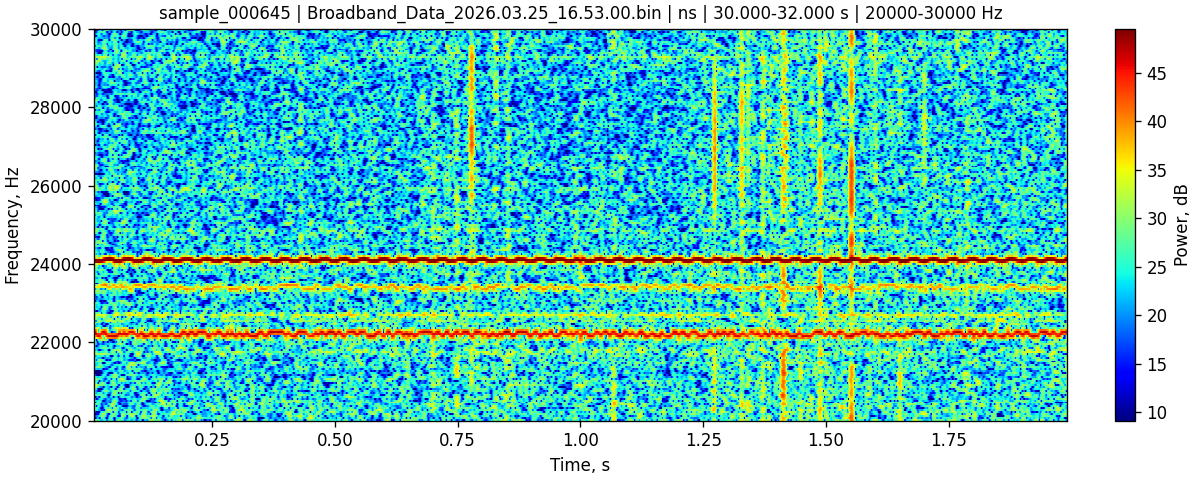

sample_000646 label= no_burst pred= burst prob_burst= 0.897


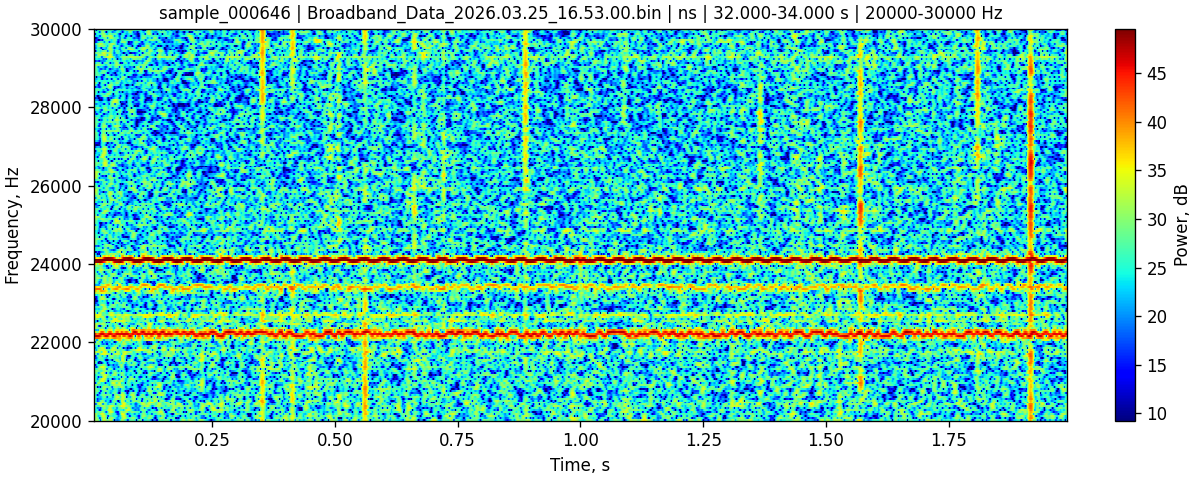

sample_000155 label= no_burst pred= burst prob_burst= 0.89


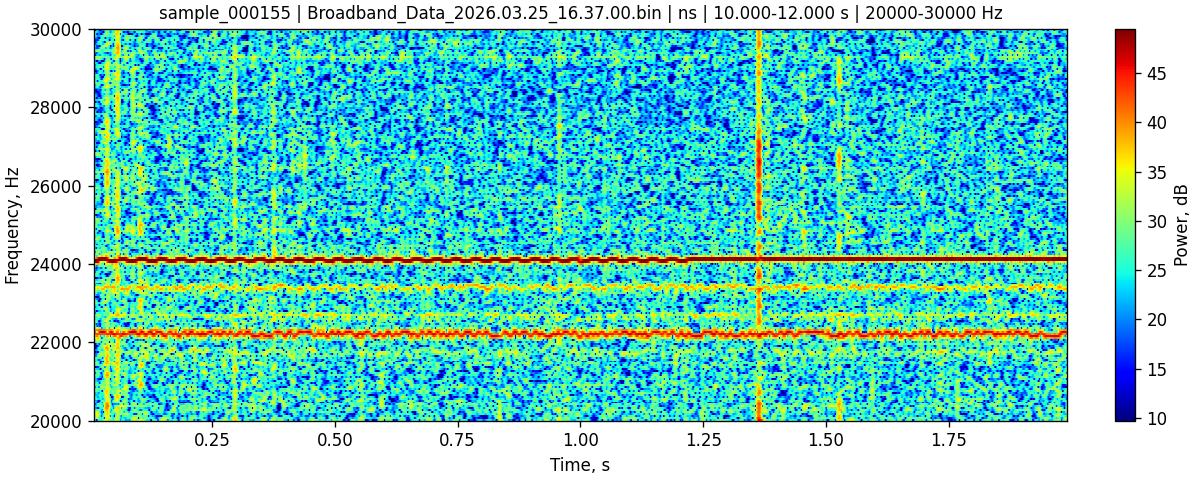

sample_000587 label= no_burst pred= burst prob_burst= 0.829


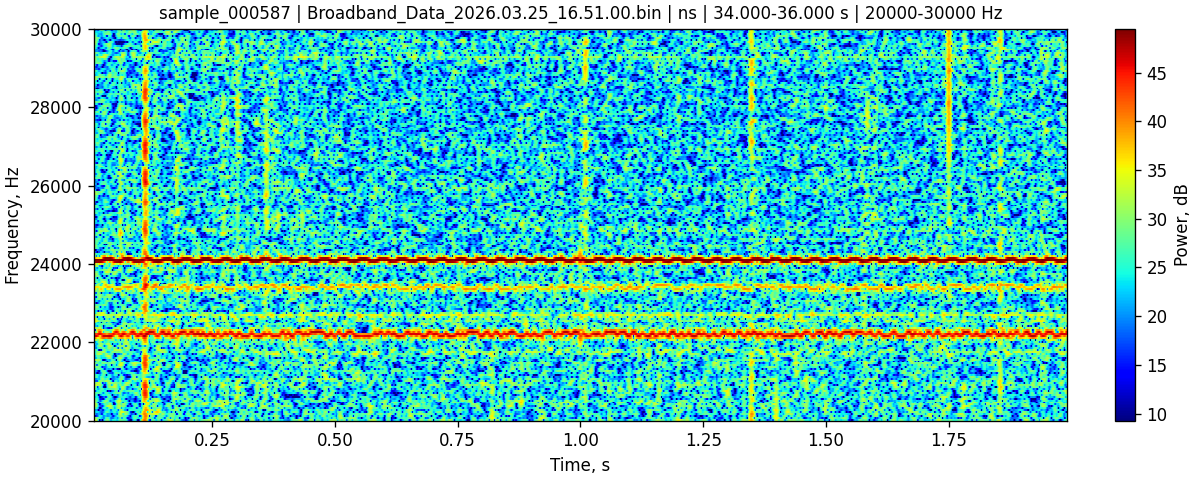

sample_000428 label= no_burst pred= burst prob_burst= 0.806


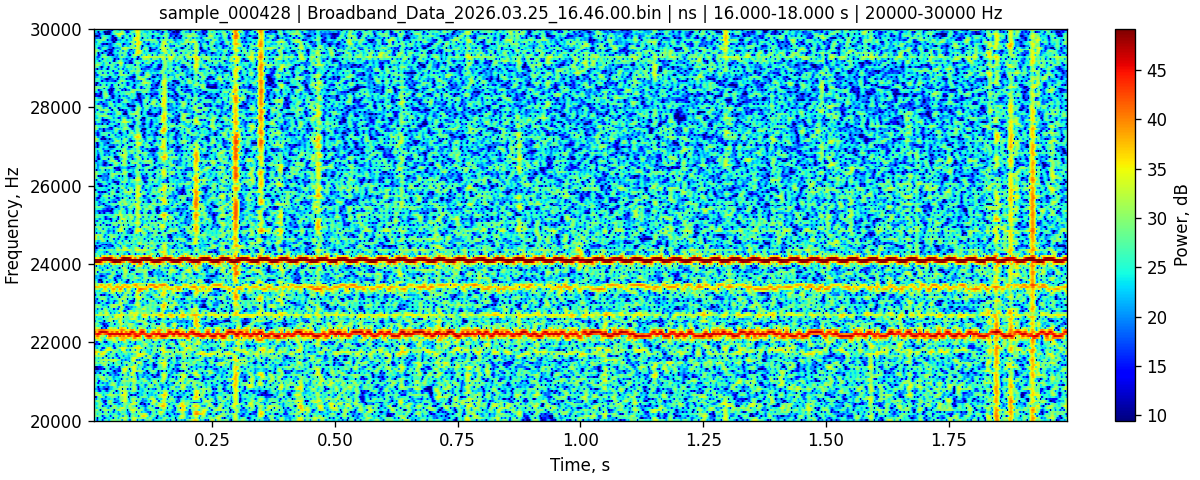

sample_000548 label= no_burst pred= burst prob_burst= 0.77


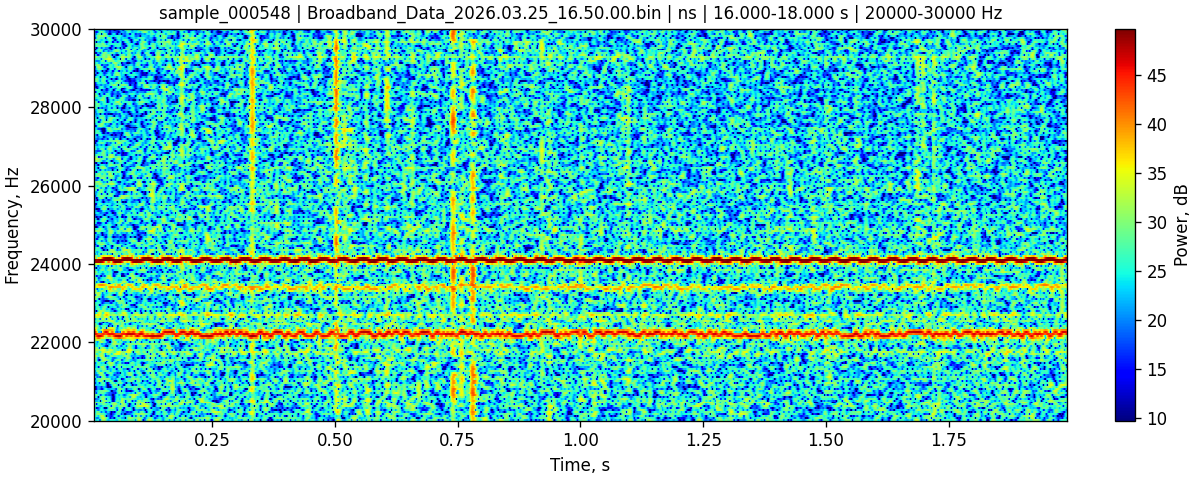

sample_000671 label= no_burst pred= burst prob_burst= 0.638


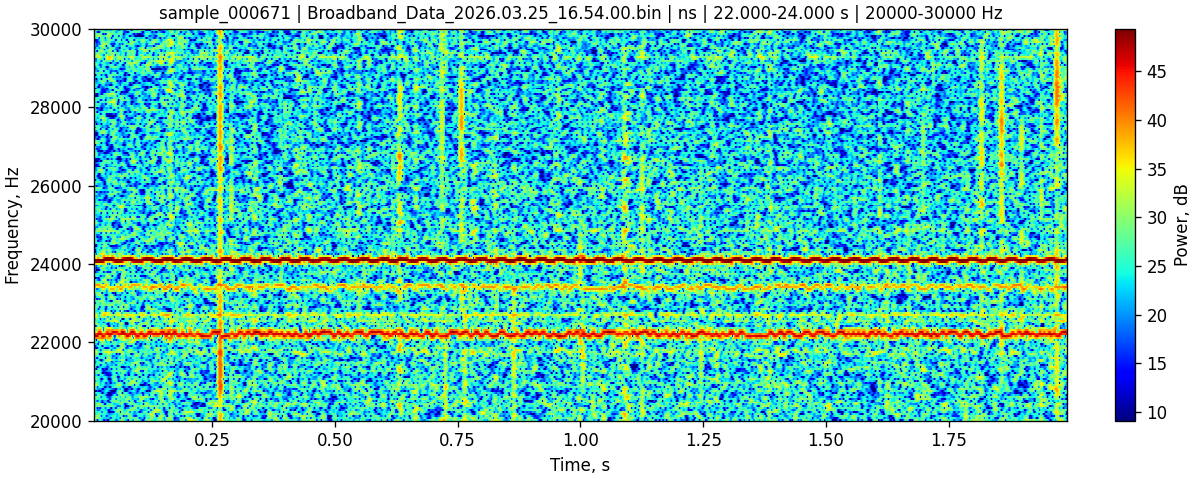

sample_000634 label= no_burst pred= burst prob_burst= 0.634


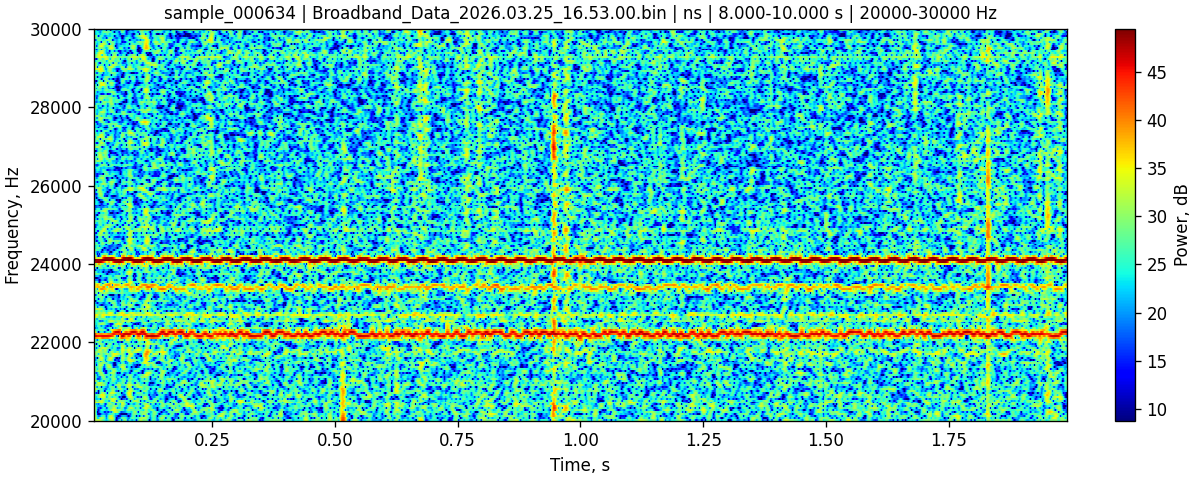

sample_000018 label= no_burst pred= burst prob_burst= 0.62


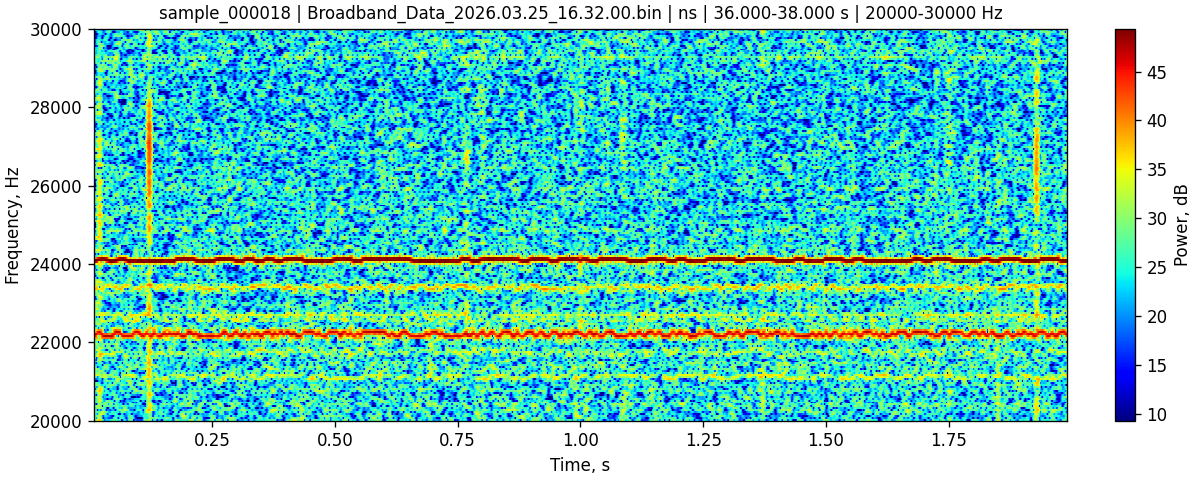

sample_000620 label= no_burst pred= burst prob_burst= 0.611


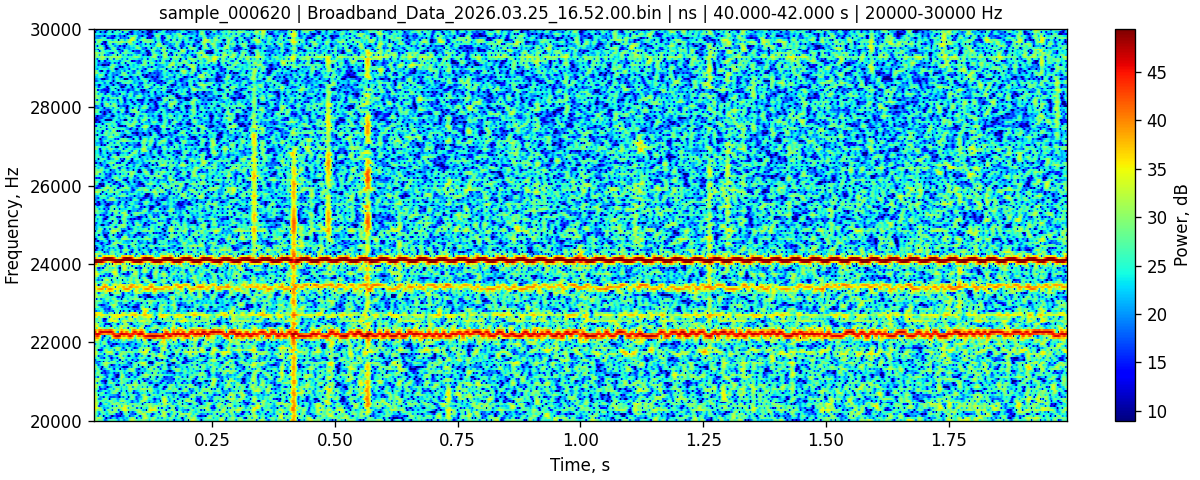

In [2]:
false_positive = pred[pred["error_type"] == "false_positive"].sort_values("prob_burst", ascending=False)

for _, row in false_positive.head(10).iterrows():
    print(row["sample_id"], "label=", row["label"], "pred=", row["predicted"], "prob_burst=", round(row["prob_burst"], 3))
    display(Image(filename=str(row["png_abs"])))


sample_000078 label= burst pred= no_burst prob_burst= 0.028


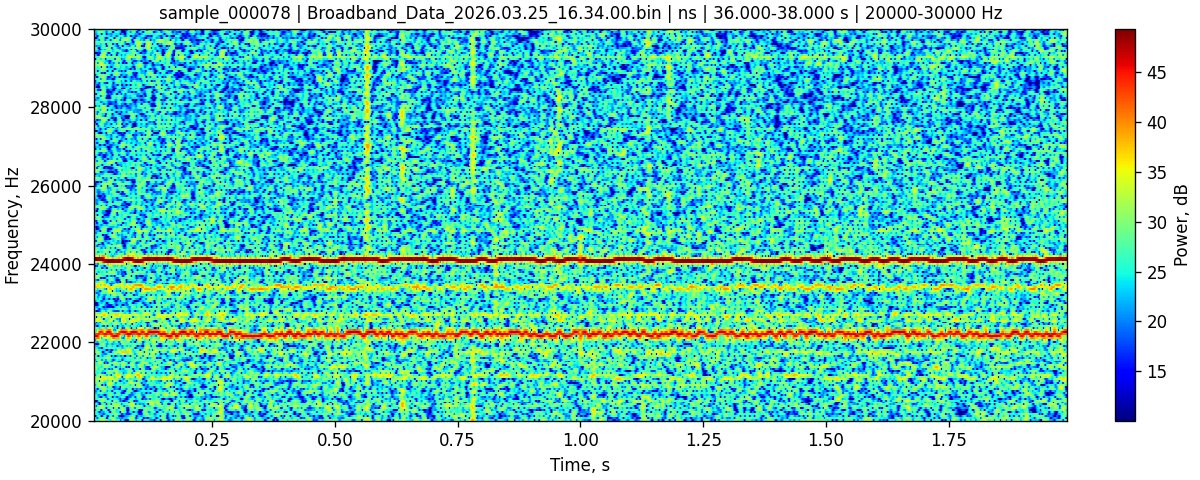

sample_000549 label= burst pred= no_burst prob_burst= 0.213


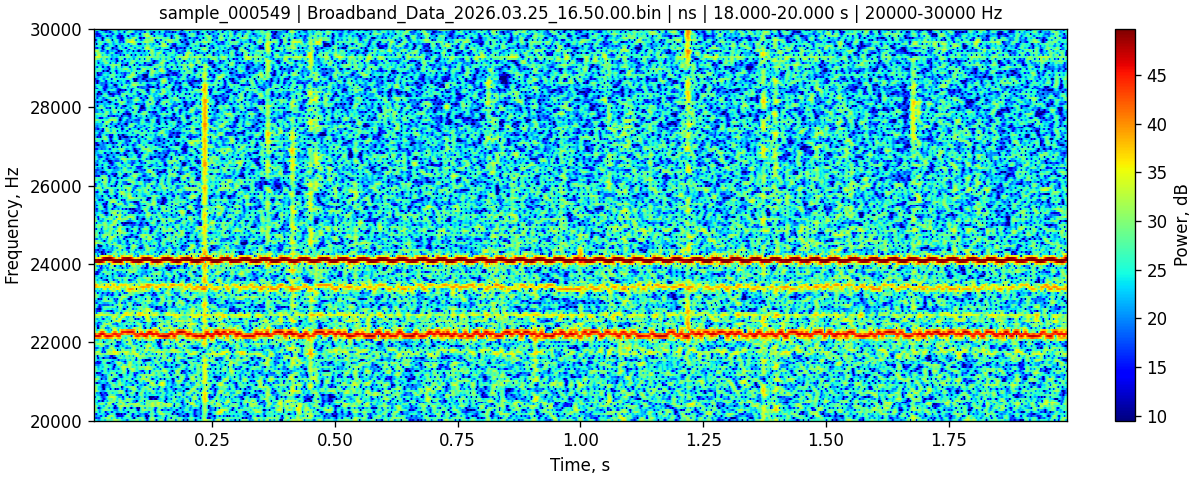

sample_000146 label= burst pred= no_burst prob_burst= 0.361


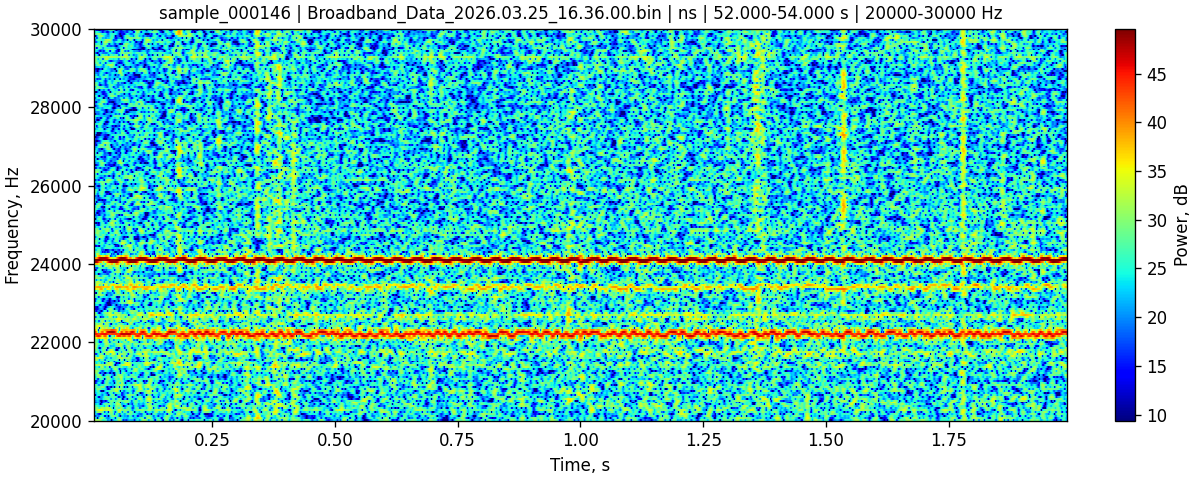

sample_000051 label= burst pred= no_burst prob_burst= 0.379


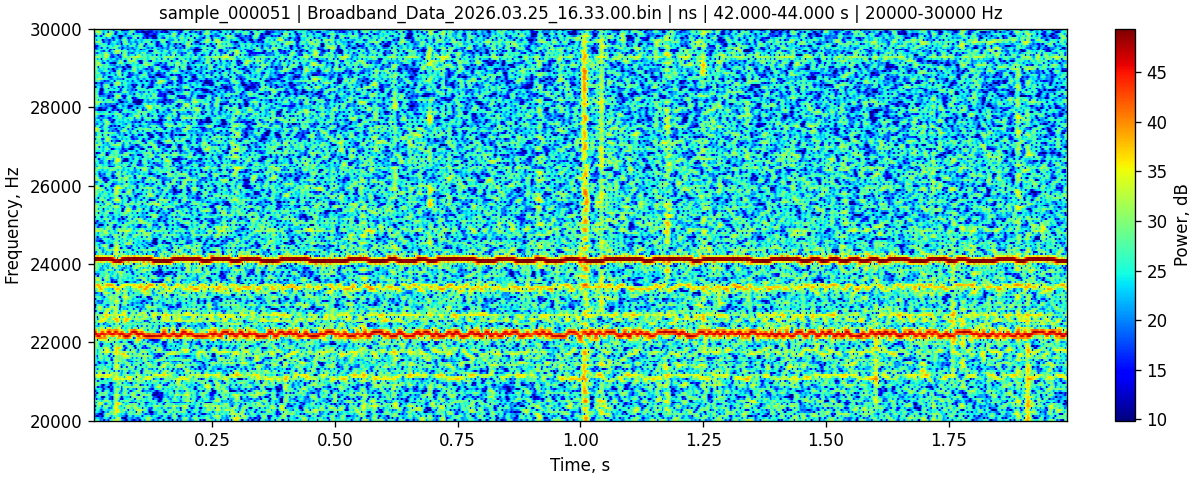

In [3]:
false_negative = pred[pred["error_type"] == "false_negative"].sort_values("prob_burst", ascending=True)

for _, row in false_negative.head(10).iterrows():
    print(row["sample_id"], "label=", row["label"], "pred=", row["predicted"], "prob_burst=", round(row["prob_burst"], 3))
    display(Image(filename=str(row["png_abs"])))
